# Potentiostat CV comparison: 1 / 2 / 3 / 4-day 10% formalin-fixed decell tissue

A purely **electrochemical** comparison of the CVs (FORCE-run + LENGTH-run per sample), all
2.5 mV/s, +1 -> -1 -> +1 V, **final cycle (scan 3)**. Day 3 has a **take-2 replicate** so its
electrochemical reproducibility is visible (take-2 drawn dashed).

**What we measure on each CV**
- **Redox peaks.** Anodic current is pinned at the +1 V vertex (capacitive — no interior oxidation
  peak), but there is a real **interior cathodic (reduction) peak** near -0.4 to -0.6 V. We detect it
  with `scipy.signal.find_peaks` and report potential `Epc`, current `ipc`, and **intensity = peak
  prominence**. Any interior anodic peak is reported likewise; otherwise the vertex is flagged capacitive.
- **Voltammetric charge** `Qa`, `Qc` = integral of i dt over positive / negative current (mC).
- **Hysteresis-loop area** = |enclosed CV area| (uA*V) — electrochemical activity per cycle.
- **Capacitance** C = (Qa + |Qc|) / (2*dV) (mF).

Each scalar is plotted vs fixation day (per-sample points + per-day mean), using the cross-section
area from `sizes.csv` for an area-normalized charge (rough proxy — true electrochemical area unknown).

In [1]:
BASE = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.16.26_formalin_fixed_decell_chicken_experiments'

In [2]:
# Config + per-SAMPLE potentiostat file map.
import os, io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy import stats

SCAN_RATE_V_PER_S = 0.0025
sizes = pd.read_csv(os.path.join(BASE, 'sizes.csv')).set_index('formalin_fixation_time')

SAMPLES = [
    dict(sid='1_DAY', day=1, key='1_DAY', label='1-day', rep=0,
         force ='potentiostat/06.18.26-1Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         length='potentiostat/06.18.26-1Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='2_DAY', day=2, key='2_DAY', label='2-day', rep=0,
         force ='potentiostat/06.15.26-2Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         length='potentiostat/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY', day=3, key='3_DAY', label='3-day t1', rep=0,
         force ='potentiostat/06.17.26-3Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         length='potentiostat/06.17.26-3Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY_take_2', day=3, key='3_DAY_take_2', label='3-day t2', rep=1,
         force ='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         length='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='4_DAY', day=4, key='4_DAY', label='4-day', rep=0,
         force ='potentiostat/06.16.26-4Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         length='potentiostat/06.16.26-4Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
]
DAY_COLOR = {1: '#9467bd', 2: '#1f77b4', 3: '#d62728', 4: '#2ca02c'}
REP_LS = {0: '-', 1: '--'}

In [3]:
# Load a CV, take its final cycle, and extract peak / charge / area / capacitance metrics.
def load_final_cycle(path):
    text = open(os.path.join(BASE, path), 'rb').read().decode('utf-16').replace('﻿', '')
    rows = [r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n = len(rows[0]) // 2
    arr = np.array([[float(x) for x in r[:2*n]] for r in rows])
    v = arr[:, 2*(n-1)]; i = arr[:, 2*(n-1) + 1]
    turn = int(np.argmin(v))
    DT = abs(v[0] - v[turn]) / turn / SCAN_RATE_V_PER_S
    return v, i, turn, DT, n

def _smooth(y, w=51, p=3):
    n = len(y); w = min(w, n if n % 2 else n-1)
    if w % 2 == 0:
        w -= 1
    return savgol_filter(y, w, p) if w > p else y

def analyze_cv(path):
    v, i, turn, DT, n = load_final_cycle(path)
    red_v, red_i = v[:turn+1], i[:turn+1]     # +1 -> -1  (reduction sweep)
    ox_v,  ox_i  = v[turn:],   i[turn:]       # -1 -> +1  (oxidation sweep)
    i_span = float(i.max() - i.min())
    prom_min = 0.02 * i_span

    rs = _smooth(red_i)
    pk, props = find_peaks(-rs, prominence=prom_min)
    if len(pk):
        k = np.argmax(props['prominences']); j = pk[k]
        Epc, ipc, prom_c, cath_interior = float(red_v[j]), float(red_i[j]), float(props['prominences'][k]), True
    else:
        j = int(np.argmin(rs)); Epc, ipc, prom_c, cath_interior = float(red_v[j]), float(red_i[j]), np.nan, False

    os_ = _smooth(ox_i)
    pk, props = find_peaks(os_, prominence=prom_min)
    if len(pk):
        k = np.argmax(props['prominences']); j = pk[k]
        Epa, ipa, prom_a, anod_interior = float(ox_v[j]), float(ox_i[j]), float(props['prominences'][k]), True
    else:
        j = int(np.argmax(os_)); Epa, ipa, prom_a, anod_interior = float(ox_v[j]), float(ox_i[j]), np.nan, False

    Qa = float(np.sum(i[i > 0]) * DT) / 1000.0          # mC, anodic
    Qc = float(np.sum(i[i < 0]) * DT) / 1000.0          # mC, cathodic
    _trap = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
    loop_area = float(abs(_trap(i, v)))                 # uA*V
    dV = float(v.max() - v.min())
    C_mF = (Qa + abs(Qc)) / (2 * dV)                    # mF

    return dict(v=v, i=i, turn=turn,
                Epc=Epc, ipc=ipc, prom_cathodic=prom_c, cath_interior=cath_interior,
                Epa=Epa, ipa=ipa, prom_anodic=prom_a, anod_interior=anod_interior,
                dEp=Epa - Epc, ipa_ipc_ratio=abs(ipa / ipc) if ipc else np.nan,
                Qa_mC=Qa, Qc_mC=Qc, Q_ratio=abs(Qa / Qc) if Qc else np.nan,
                loop_area_uAV=loop_area, C_mF=C_mF, i_span_uA=i_span)

In [4]:
# Analyze every CV (FORCE-run + LENGTH-run per sample).
results = {}   # (sid, run) -> metrics dict
records = []
for s in SAMPLES:
    area = float(sizes.loc[s['key'], 'width(mm)']) * float(sizes.loc[s['key'], 'thickness(mm)'])
    for run in ('force', 'length'):
        m = analyze_cv(s[run]); results[(s['sid'], run)] = m
        rec = {k: v for k, v in m.items() if k not in ('v', 'i', 'turn')}
        rec.update(sid=s['sid'], day=s['day'], label=s['label'], run=run,
                   area_mm2=round(area, 4), Qa_per_mm2=m['Qa_mC'] / area)
        records.append(rec)

cols = ['label', 'day', 'run', 'Epc', 'ipc', 'prom_cathodic', 'Epa', 'ipa', 'anod_interior',
        'dEp', 'ipa_ipc_ratio', 'Qa_mC', 'Qc_mC', 'Q_ratio', 'loop_area_uAV', 'C_mF',
        'area_mm2', 'Qa_per_mm2']
metrics = pd.DataFrame(records)[cols].sort_values(['day', 'label', 'run']).reset_index(drop=True)
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print('Per-CV electrochemical metrics (final cycle).  anod_interior=False -> ipa/Epa are the +1 V vertex.')
metrics

Per-CV electrochemical metrics (final cycle).  anod_interior=False -> ipa/Epa are the +1 V vertex.


,label,day,run,Epc,ipc,prom_cathodic,Epa,ipa,anod_interior,dEp,ipa_ipc_ratio,Qa_mC,Qc_mC,Q_ratio,loop_area_uAV,C_mF,area_mm2,Qa_per_mm2
0,1-day,1,force,-0.582,-1695.710,720.848,0.999,2495.470,False,1.581,1.472,905.147,-748.927,1.209,2365.717,413.405,1.440,628.574
1,1-day,1,length,-0.592,-1672.550,667.295,0.999,2440.390,False,1.591,1.459,887.010,-742.916,1.194,2340.736,407.369,1.440,615.979
2,2-day,2,force,-0.469,-1758.270,987.686,0.999,2241.740,False,1.468,1.275,830.682,-831.603,0.999,2895.368,415.457,1.260,659.271
3,2-day,2,length,-0.456,-1455.050,821.401,0.999,2069.740,False,1.455,1.422,712.890,-650.853,1.095,1937.242,340.842,1.260,565.785
4,3-day t1,3,force,-0.448,-1787.480,936.374,0.999,3165.380,False,1.447,1.771,1075.572,-799.995,1.344,2624.673,468.763,1.321,814.457
5,3-day t1,3,length,-0.457,-1799.020,902.299,0.999,3044.590,False,1.456,1.692,1057.023,-815.507,1.296,2664.049,468.004,1.321,800.411
6,3-day t2,3,force,-0.667,-1408.030,514.432,0.940,1993.120,False,1.606,1.416,775.836,-596.019,1.302,1558.263,343.124,1.740,445.883
7,3-day t2,3,length,-0.704,-1292.500,354.426,0.998,1943.570,False,1.702,1.504,730.548,-565.734,1.291,1381.624,324.222,1.740,419.855
8,4-day,4,force,-0.413,-2500.850,1612.725,0.999,3117.830,False,1.412,1.247,1172.902,-1174.163,0.999,4495.686,586.605,1.272,922.383
9,4-day,4,length,-0.402,-2501.330,1534.403,0.999,3143.630,False,1.401,1.257,1171.352,-1182.932,0.990,4513.415,588.409,1.272,921.164


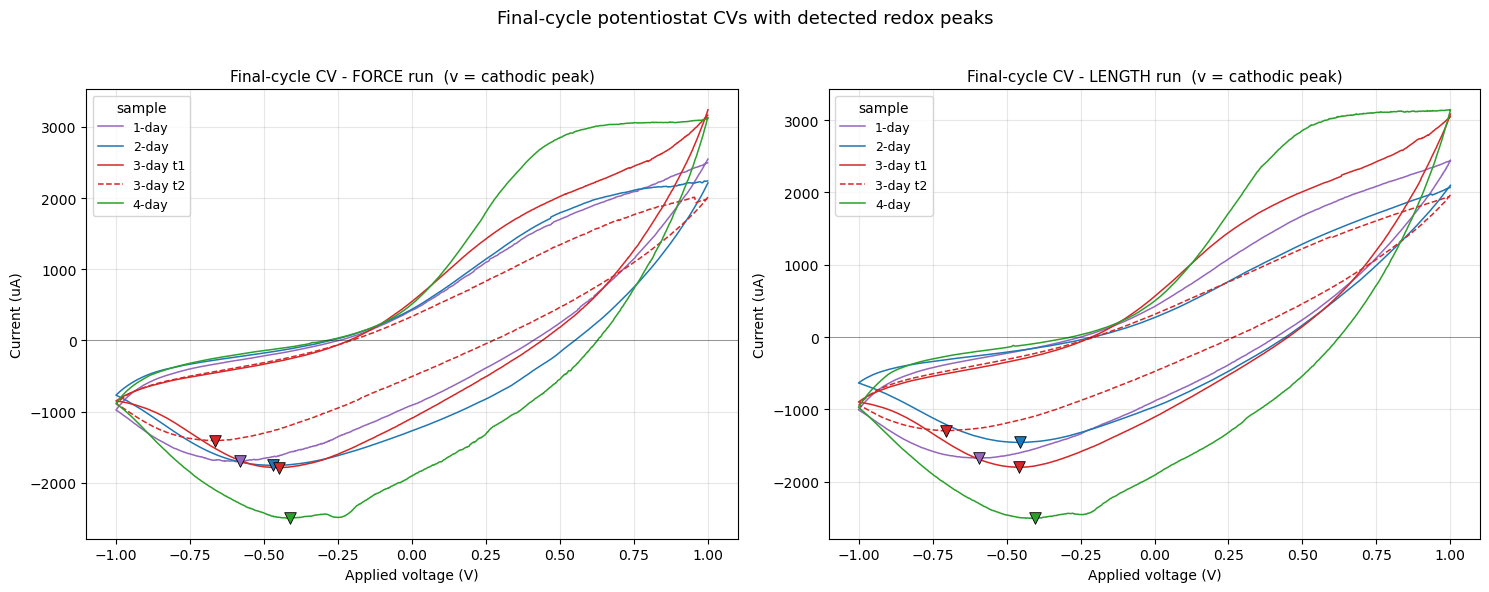

In [5]:
# Overlay final-cycle CVs with detected cathodic peaks (v). Left FORCE-run, right LENGTH-run; take-2 dashed.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for col, run in enumerate(('force', 'length')):
    ax = axes[col]
    for s in SAMPLES:
        m = results[(s['sid'], run)]; c, ls = DAY_COLOR[s['day']], REP_LS[s['rep']]
        ax.plot(m['v'], m['i'], color=c, ls=ls, lw=1.1, label=s['label'])
        ax.scatter([m['Epc']], [m['ipc']], color=c, marker='v', s=70, ec='k', lw=0.6, zorder=5)
        if m['anod_interior']:
            ax.scatter([m['Epa']], [m['ipa']], color=c, marker='^', s=70, ec='k', lw=0.6, zorder=5)
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_xlabel('Applied voltage (V)'); ax.set_ylabel('Current (uA)')
    ax.set_title(f'Final-cycle CV - {run.upper()} run  (v = cathodic peak)', fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(title='sample', fontsize=9)
fig.suptitle('Final-cycle potentiostat CVs with detected redox peaks', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

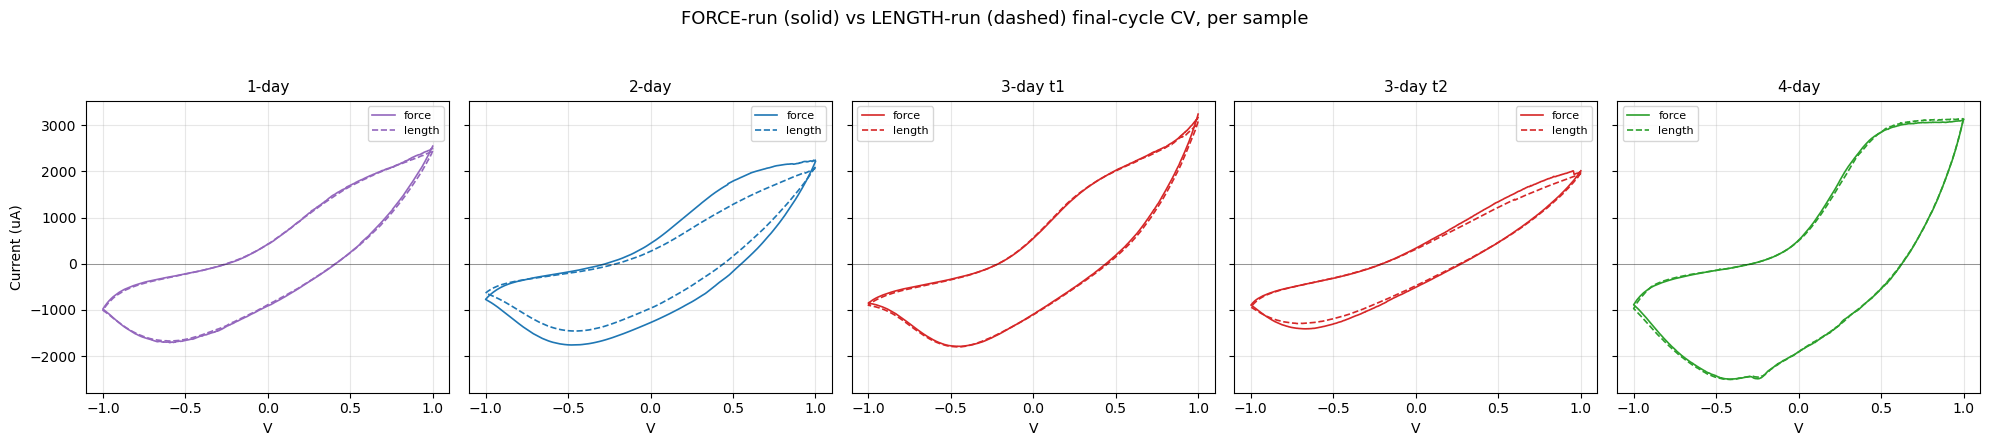

In [6]:
# FORCE-run vs LENGTH-run CV per sample (sequential runs on the same sample).
n = len(SAMPLES)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4.5), sharey=True)
for ax, s in zip(axes, SAMPLES):
    for run, ls in (('force', '-'), ('length', '--')):
        m = results[(s['sid'], run)]
        ax.plot(m['v'], m['i'], ls, color=DAY_COLOR[s['day']], lw=1.2, label=run)
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_title(s['label'], fontsize=11); ax.set_xlabel('V'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel('Current (uA)')
fig.suptitle('FORCE-run (solid) vs LENGTH-run (dashed) final-cycle CV, per sample', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

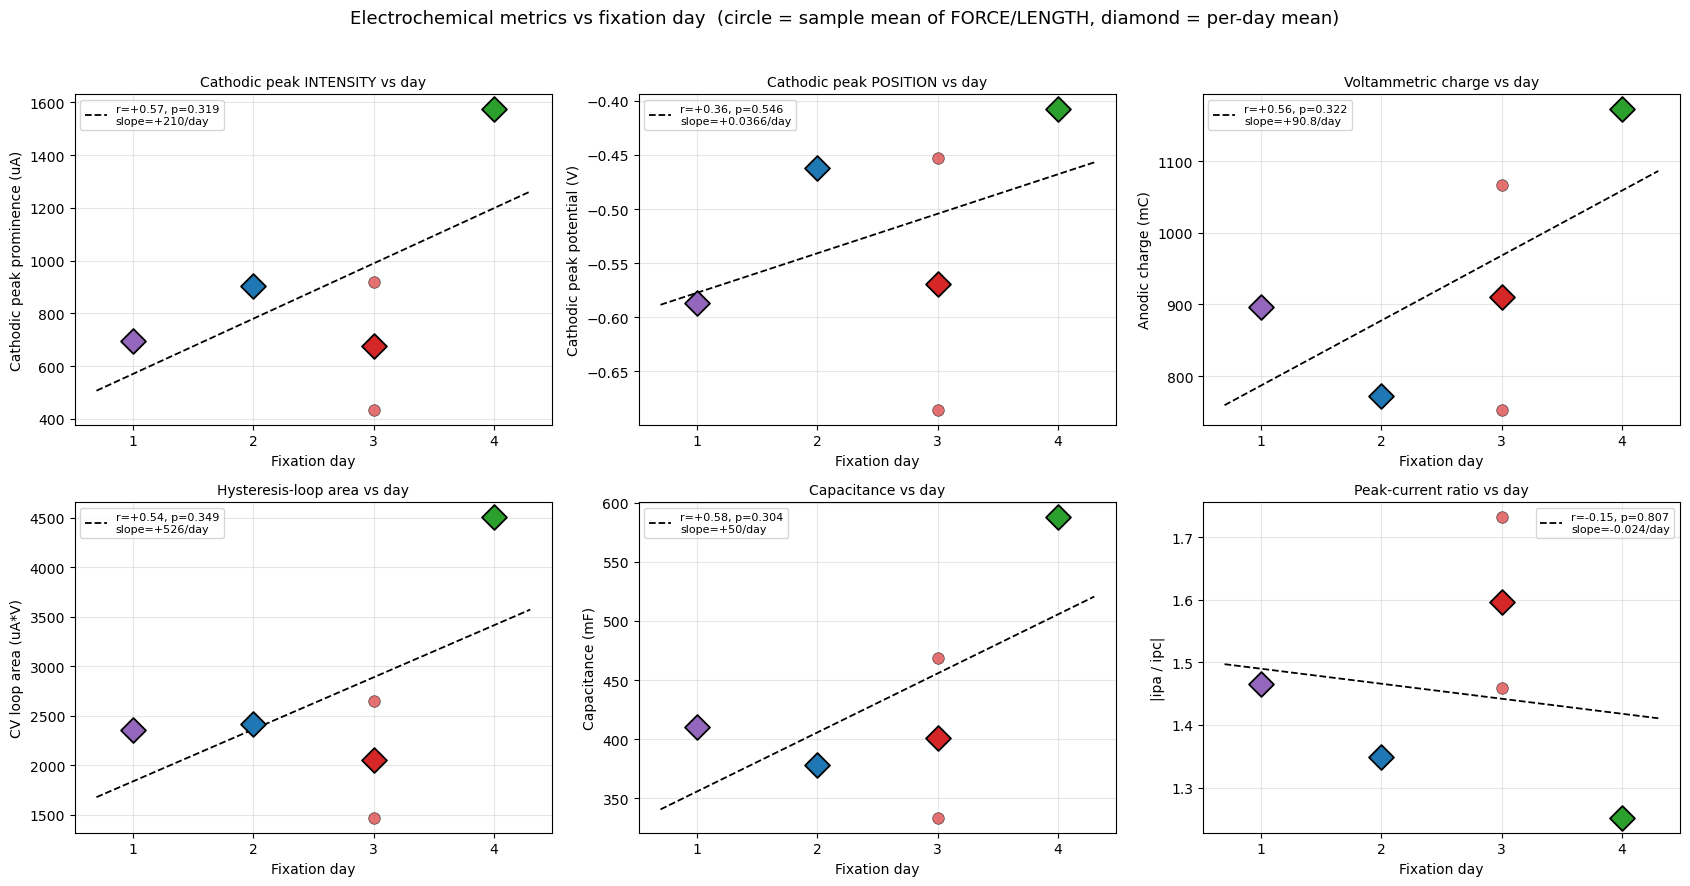

In [7]:
# Scalar metrics vs fixation day. Per sample we average the FORCE & LENGTH runs (repeats);
# circles = samples, diamonds = per-day mean, dashed = all-sample fit.
def day_trend(ax, metric, ylabel, title):
    rows = []
    for s in SAMPLES:
        vals = [results[(s['sid'], r)][metric] for r in ('force', 'length')]
        vals = [v for v in vals if v == v]
        if vals:
            rows.append((s['day'], float(np.mean(vals))))
    x = np.array([r[0] for r in rows], float); y = np.array([r[1] for r in rows], float)
    for xi, yi in zip(x, y):
        ax.scatter(xi, yi, s=70, color=DAY_COLOR[int(xi)], ec='k', lw=0.5, alpha=0.65, zorder=4)
    dfm = pd.DataFrame({'d': x, 'y': y}).groupby('d')['y'].mean()
    for d, m in dfm.items():
        ax.scatter(d, m, s=160, color=DAY_COLOR[int(d)], ec='k', lw=1.3, marker='D', zorder=5)
    sl, ic, r, p, se = stats.linregress(x, y)
    xx = np.linspace(x.min()-0.3, x.max()+0.3, 40)
    ax.plot(xx, ic + sl*xx, 'k--', lw=1.3, label=f'r={r:+.2f}, p={p:.3f}\nslope={sl:+.3g}/day')
    ax.set_xlabel('Fixation day'); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=10)
    ax.set_xticks(sorted(set(x.astype(int)))); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
day_trend(axes[0,0], 'prom_cathodic', 'Cathodic peak prominence (uA)', 'Cathodic peak INTENSITY vs day')
day_trend(axes[0,1], 'Epc',           'Cathodic peak potential (V)',  'Cathodic peak POSITION vs day')
day_trend(axes[0,2], 'Qa_mC',         'Anodic charge (mC)',           'Voltammetric charge vs day')
day_trend(axes[1,0], 'loop_area_uAV', 'CV loop area (uA*V)',          'Hysteresis-loop area vs day')
day_trend(axes[1,1], 'C_mF',          'Capacitance (mF)',             'Capacitance vs day')
day_trend(axes[1,2], 'ipa_ipc_ratio', '|ipa / ipc|',                  'Peak-current ratio vs day')
fig.suptitle('Electrochemical metrics vs fixation day  (circle = sample mean of FORCE/LENGTH, diamond = per-day mean)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

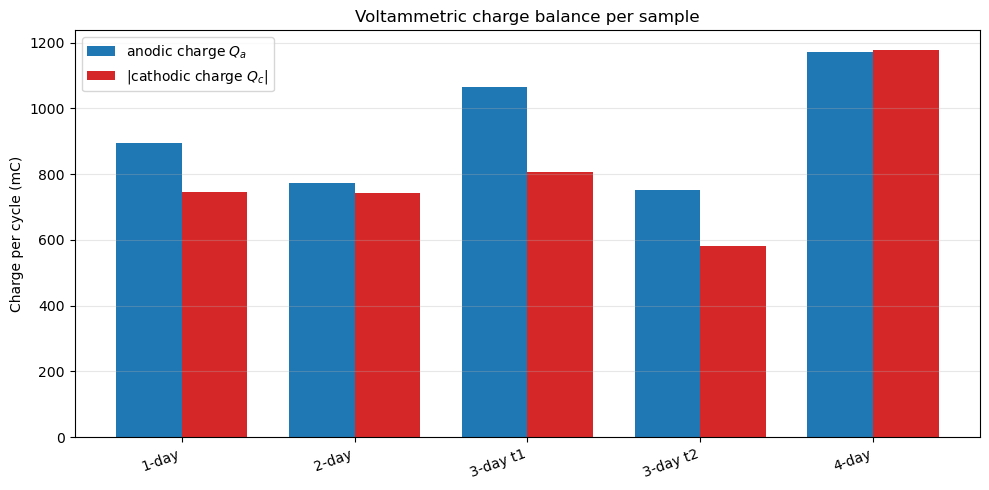

Per-sample means (mC):
  1-day    : Qa=896.079, |Qc|=745.922, Qa/|Qc|=1.201
  2-day    : Qa=771.786, |Qc|=741.228, Qa/|Qc|=1.041
  3-day t1 : Qa=1066.297, |Qc|=807.751, Qa/|Qc|=1.320
  3-day t2 : Qa=753.192, |Qc|=580.876, Qa/|Qc|=1.297
  4-day    : Qa=1172.127, |Qc|=1178.548, Qa/|Qc|=0.995


In [8]:
# Charge balance per sample: anodic vs |cathodic| voltammetric charge (FORCE/LENGTH averaged).
labels = [s['label'] for s in SAMPLES]
Qa = [np.mean([results[(s['sid'], r)]['Qa_mC'] for r in ('force', 'length')]) for s in SAMPLES]
Qc = [np.mean([abs(results[(s['sid'], r)]['Qc_mC']) for r in ('force', 'length')]) for s in SAMPLES]
x = np.arange(len(SAMPLES)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, Qa, w, label='anodic charge $Q_a$', color='#1f77b4')
ax.bar(x + w/2, Qc, w, label='|cathodic charge $Q_c$|', color='#d62728')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Charge per cycle (mC)'); ax.set_title('Voltammetric charge balance per sample')
ax.grid(True, axis='y', alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()
print('Per-sample means (mC):')
for lab, a, c in zip(labels, Qa, Qc):
    print(f'  {lab:9}: Qa={a:.3f}, |Qc|={c:.3f}, Qa/|Qc|={a/c:.3f}')

## How to read this

- **Cathodic peak intensity (prominence)** and **position (Epc)** are the cleanest faradaic signals;
  the anodic side is capacitive (pinned at the +1 V vertex) unless `anod_interior` is True.
- The **day-3 take-2** CV (dashed) sits next to take-1 — if its peak/charge metrics land near take-1,
  the electrochemistry is reproducible and any mechanical difference is a coupling/geometry effect;
  if they differ too, it was a genuinely different sample.
- **Epc shift** toward less-negative = easier/more reversible reduction; widening **ΔEp** = sluggish.
- **Qa/|Qc|** ≈ 1 = reversible, charge-balanced cycle.
- Pair these electrochemical trends with the mechanical stress/strain trends in
  `formalin_day_comparison.ipynb` — they should tell the same story if the actuation is faradaic.